In [9]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl
import csv

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Catalog

HSC Y3 Matched from Jared

In [10]:
# hscy3 = '/scratch/gpfs/js1998/matched_catalogs/hscy3_matched.csv'
hscy3 = '/scratch/gpfs/dy9683/matched_catalogs/hscy3_matched_lensing_match_1.csv'

In [11]:
# file_path = hscy3
# hsc_catalog = pl.scan_csv(file_path).filter(pl.col('lensing_match') == 1).collect()
# hsc_catalog.write_csv("/scratch/gpfs/dy9683/matched_catalogs/hscy3_matched_lensing_match_1.csv")

In [12]:
hsc_catalog = pd.read_csv(hscy3)

In [10]:
hsc_catalog

,Unnamed: 0,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,...,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,e_rms,lensing_weight,m_corr,lensing_match
0,266644,-415623332,b'main',b'backup',41562,20220127,1.508132,0,0.000072,5,...,0,0,183.987353,-0.686717,-0.160963,0.243101,0.417247,5.505575,-0.101984,1
1,266679,-415623282,b'main',b'backup',41562,20220127,1.477694,0,0.000195,2049,...,0,0,184.246610,-0.432773,-0.274310,-0.403104,0.400365,6.235699,-0.075364,1
2,266790,-415623467,b'main',b'backup',41562,20220127,1.412716,0,0.000124,1,...,0,0,183.931488,-0.365314,-0.675388,0.319786,0.372636,7.166719,-0.099273,1
3,266919,-415623291,b'main',b'backup',41562,20220127,1.484783,0,0.000096,2049,...,0,0,184.432631,-0.105660,0.252211,-0.214084,0.397458,4.774204,-0.153505,1
4,267070,-415624308,b'main',b'backup',41562,20220127,1.197444,0,0.000077,5,...,0,0,184.908630,0.367061,0.287382,-0.323245,0.394542,6.389355,-0.095913,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358420,120373439,39627758111823245,b'sv3',b'dark',521,20210610,1.493829,3,0.000189,0,...,0,0,213.746366,-1.311083,-0.205629,0.055689,0.390456,6.306665,-0.088108,1
1358421,120373440,39627758111822197,b'sv3',b'dark',521,20210610,1.033031,3,0.000052,0,...,0,0,213.699911,-1.332446,0.400157,-0.031770,0.373179,7.088258,-0.077363,1
1358422,120373470,39627752067831364,b'sv3',b'dark',521,20210610,0.891046,3,0.000035,0,...,0,0,213.484725,-1.407819,-0.416264,-0.300840,0.393393,6.428363,-0.084723,1
1358423,120373473,39627752067830534,b'sv3',b'dark',521,20210610,1.411382,3,0.000106,0,...,0,0,213.451322,-1.383700,-0.183284,0.484148,0.389562,5.449132,-0.060374,1


In [13]:
def get_duplicate_numbers(file_path, column_index):
    seen = set()
    duplicates = set()
    
    with open(file_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip the header row
        
        for row in reader:
            value = row[column_index]
            
            # If we've seen it before, add it to our duplicates set
            if value in seen:
                duplicates.add(value)
            else:
                # Otherwise, log that we've seen it for the first time
                seen.add(value)
                
    return duplicates

In [16]:
duplicate_numbers = get_duplicate_numbers(hscy3, 0)

print(f"The following numbers are not unique: {duplicate_numbers}")

The following numbers are not unique: set()


In [18]:
df = pd.read_csv(hscy3, dtype={"TARGETID": str})
duplicate_rows = df[df.duplicated(subset=["TARGETID"], keep=False)]
print(duplicate_rows["TARGETID"].unique())

<StringArray>
['616088540131886277', '616088569823363126', '616088528190702246',
 '616088539578237300', '616088509257614427', '616088558746207241',
 '616088546058436874', '616088558146421349', '616088509878370346',
 '616088534050144428',
 ...
  '39627758107625425',  '39627776201855920',  '39627782250039260',
  '39627794333831484',  '39627800386209756',  '39627782275204229',
  '39627764151621427',  '39627758116015457',  '39627764151619387',
  '39627752063635538']
Length: 239586, dtype: str


In [10]:
ra = hsc_catalog['TARGET_RA']
dec = hsc_catalog['TARGET_DEC']
g1 = hsc_catalog['e1'] 
g2 = hsc_catalog['e2']
z = hsc_catalog['Z_BEST']

# Plots

In [11]:
print(f'Number of sources: {len(hsc_catalog):,}')

Number of sources: 1,358,425


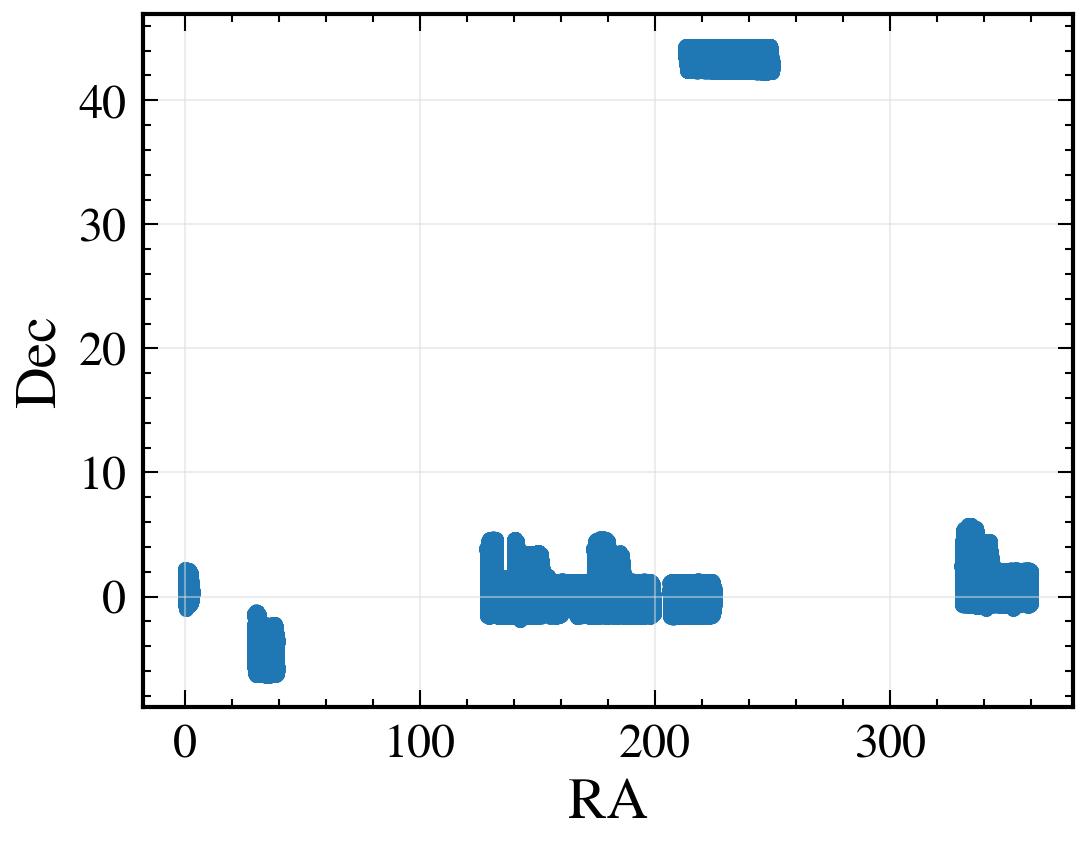

In [70]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

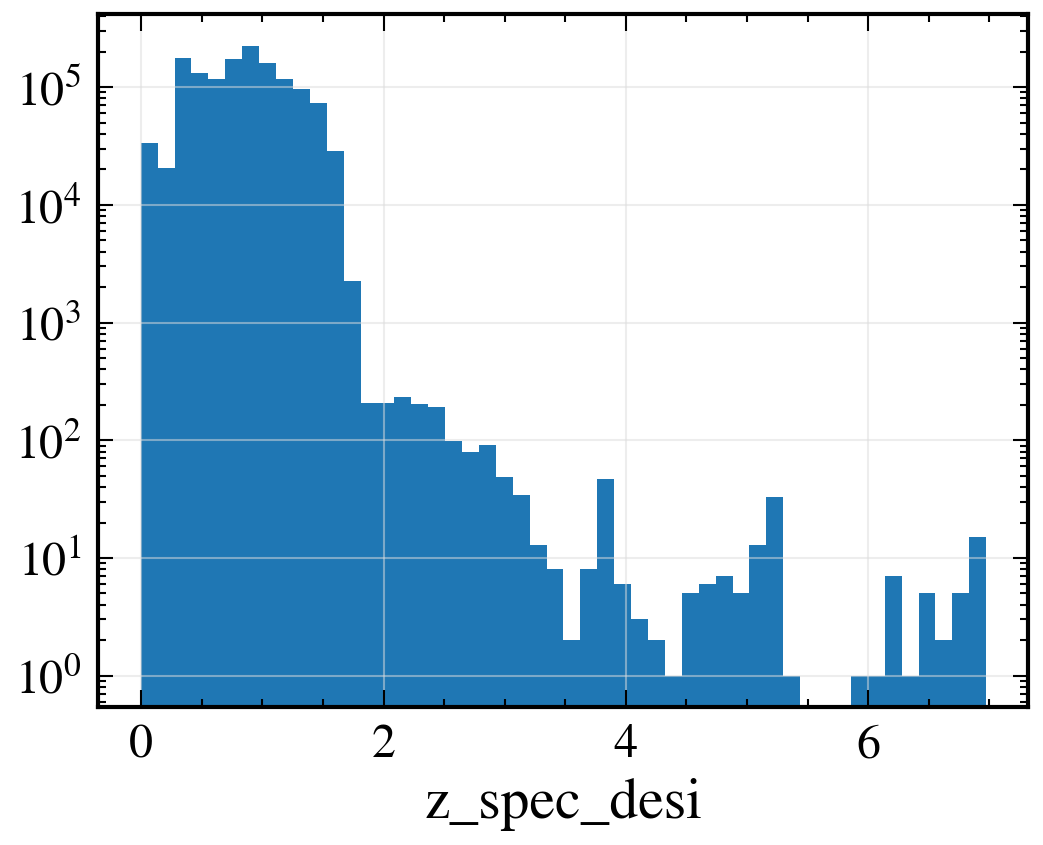

In [71]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [63]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation func tions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [64]:
xip

array([ 7.96474311e-04, -2.92355020e-04, -9.18420845e-05,  6.04405603e-04,
        3.36623779e-04,  3.79145697e-04,  3.20022929e-04,  1.01394239e-04,
        3.98168415e-05, -1.08792029e-05, -4.84039191e-05,  1.37992998e-06,
        4.07009731e-05,  6.51792123e-05,  2.55598238e-05,  1.77295350e-05,
        1.05124731e-05,  3.92684100e-08,  9.57152928e-06, -6.85843262e-06])

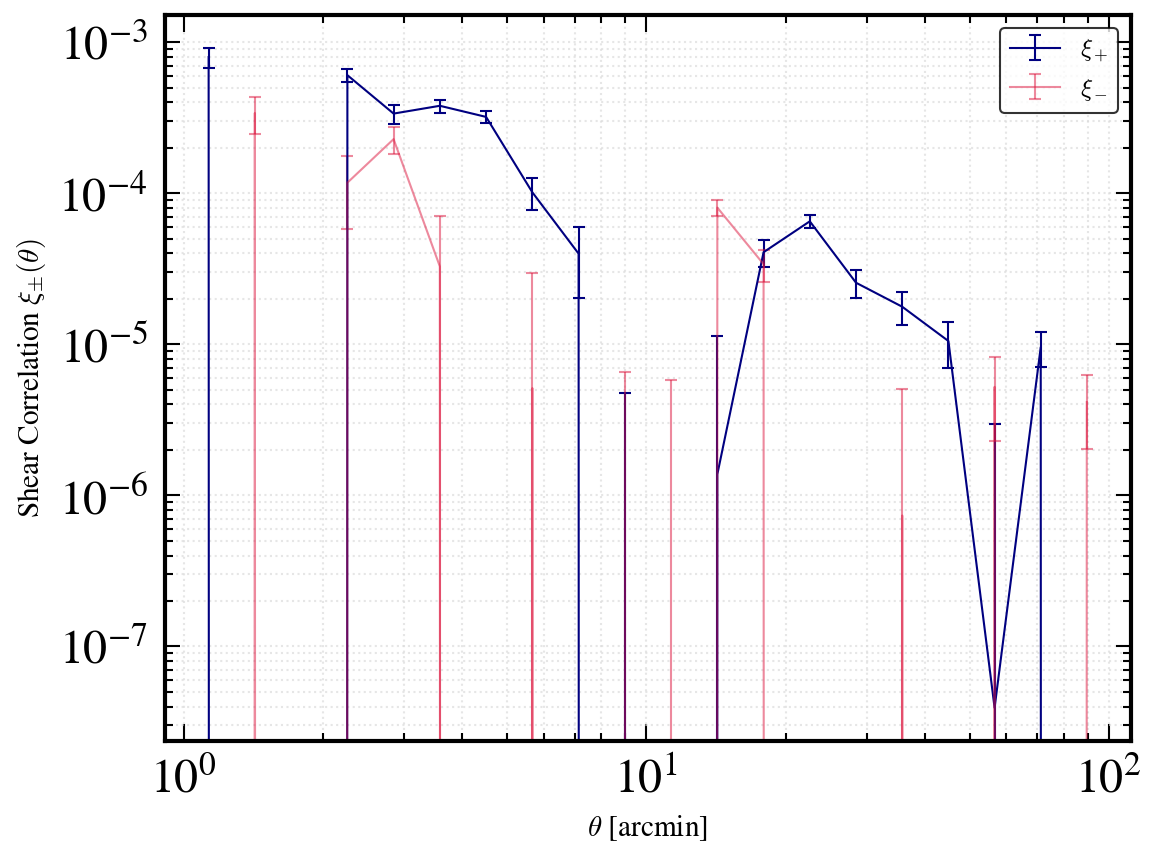

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3, fmt = "o")
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

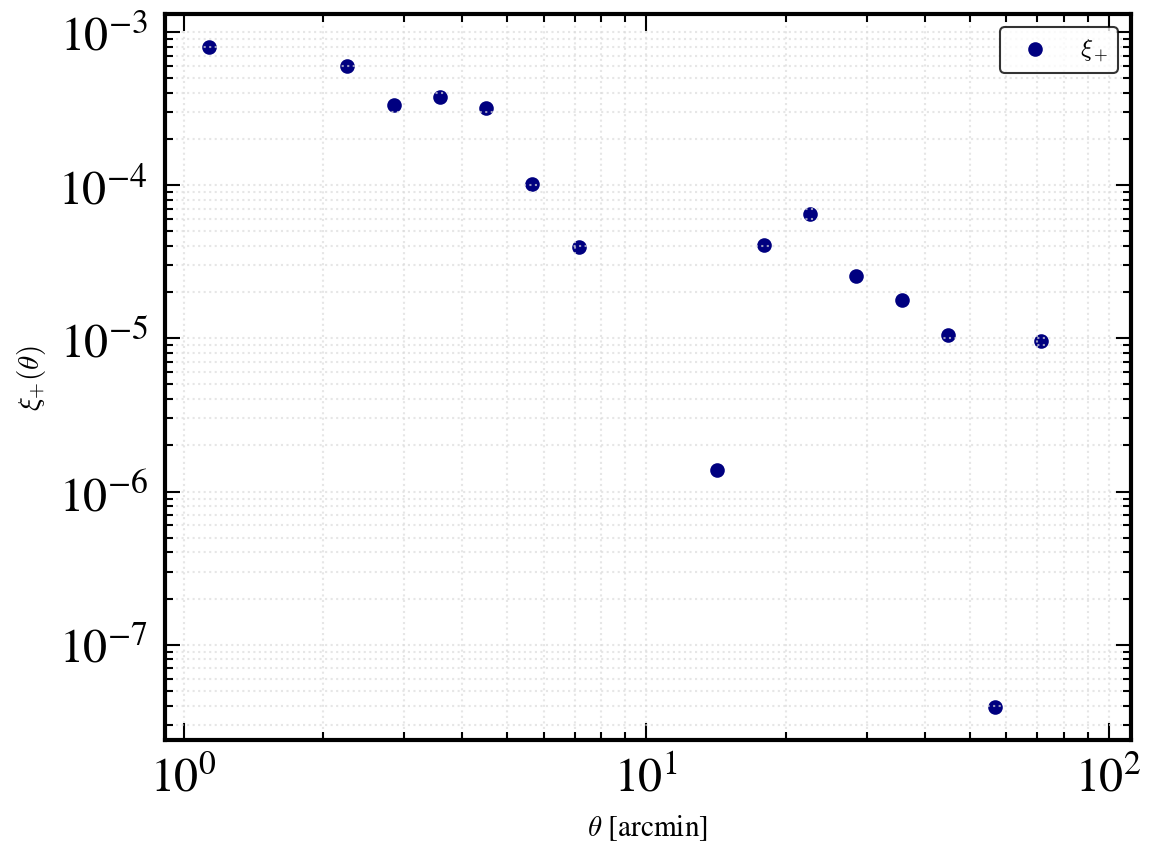

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Sanity Checks

In [12]:
z_threshold = np.percentile(hsc_catalog['Z_BEST'], 66.67)

mask_top = hsc_catalog['Z_BEST'] > z_threshold
mask_bottom = hsc_catalog['Z_BEST'] <= z_threshold

hsc_top_third = hsc_catalog[mask_top]
hsc_bottom_two_thirds = hsc_catalog[mask_bottom]

In [39]:
np.max(hsc_bottom_two_thirds['Z_BEST'])

np.float64(0.9921172850695232)

In [14]:
print(f'Number of sources for top third of redshift: {len(hsc_top_third):,}')
print(f'Number of sources for bottom two thirds of redshift: {len(hsc_bottom_two_thirds):,}')

Number of sources for top third of redshift: 452,763
Number of sources for bottom two thirds of redshift: 905,662


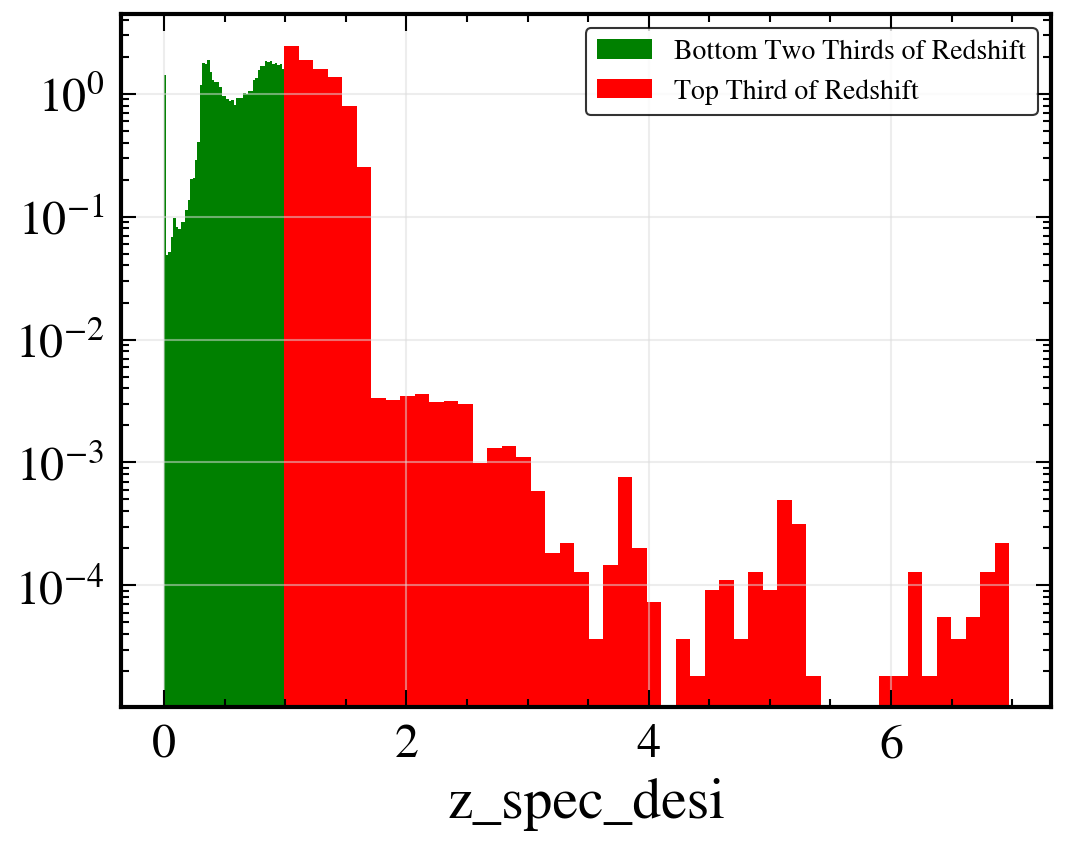

In [24]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(hsc_bottom_two_thirds['Z_BEST'], bins = 50 , density = True, color = "green", label = "Bottom Two Thirds of Redshift")
ax.hist(hsc_top_third['Z_BEST'], bins = 50 , density = True, color = "red", label = "Top Third of Redshift")
ax.legend()
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

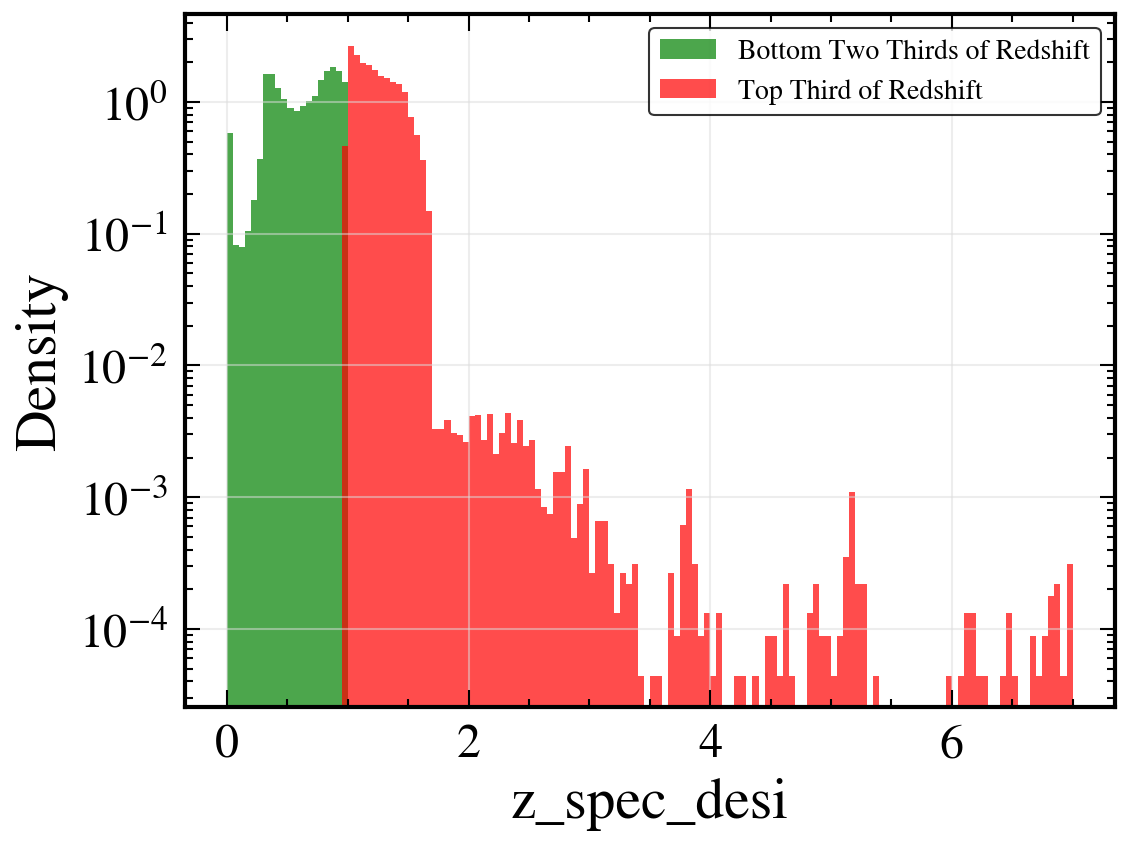

In [27]:
max_z = max(hsc_bottom_two_thirds['Z_BEST'].max(), hsc_top_third['Z_BEST'].max())
shared_bins = np.arange(0, max_z + 0.05, 0.05)

fig, ax = plt.subplots(figsize=(8,6))

ax.hist(hsc_bottom_two_thirds['Z_BEST'], bins=shared_bins, density=True, color="green", alpha=0.7, label="Bottom Two Thirds of Redshift")
ax.hist(hsc_top_third['Z_BEST'], bins=shared_bins, density=True, color="red", alpha=0.7, label="Top Third of Redshift")

ax.legend()
ax.set_xlabel("z_spec_desi")
ax.set_ylabel("Density")
ax.set_yscale('log')
plt.show()

In [29]:
ra_top_third = hsc_top_third['TARGET_RA']
dec_top_third = hsc_top_third['TARGET_DEC']
g1_top_third = hsc_top_third['e1'] 
g2_top_third = hsc_top_third['e2']

In [28]:
ra_bottom_two_third = hsc_bottom_two_thirds['TARGET_RA']
dec_bottom_two_third = hsc_bottom_two_thirds['TARGET_DEC']
g1_bottom_two_third = hsc_bottom_two_thirds['e1'] 
g2_bottom_two_third = hsc_bottom_two_thirds['e2']

In [31]:
cat_top_third = treecorr.Catalog(ra=ra_top_third, dec=dec_top_third, g1=g1_top_third, g2=g2_top_third, ra_units='degrees', dec_units='degrees')
gg_top_third = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_top_third.process(cat_top_third)

r_top_third = np.exp(gg_top_third.meanlogr)

# correlation functions
#xi_+
xip_top_third = gg_top_third.xip
# # xi_-
xim_top_third = gg_top_third.xim

#calculate variance
sig_xip_top_third = np.sqrt(gg_top_third.varxip)
sig_xim_top_third = np.sqrt(gg_top_third.varxim)

In [32]:
cat_bottom_two_third = treecorr.Catalog(ra=ra_bottom_two_third, dec=dec_bottom_two_third, g1=g1_bottom_two_third, g2=g2_bottom_two_third, ra_units='degrees', dec_units='degrees')
gg_bottom_two_third = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_bottom_two_third.process(cat_bottom_two_third)

r_bottom_two_third = np.exp(gg_bottom_two_third.meanlogr)

# correlation func tions
#xi_+
xip_bottom_two_third = gg_bottom_two_third.xip
# # xi_-
xim_bottom_two_third = gg_bottom_two_third.xim

#calculate variance
sig_xip_bottom_two_third = np.sqrt(gg_bottom_two_third.varxip)
sig_xim_bottom_two_third = np.sqrt(gg_bottom_two_third.varxim)

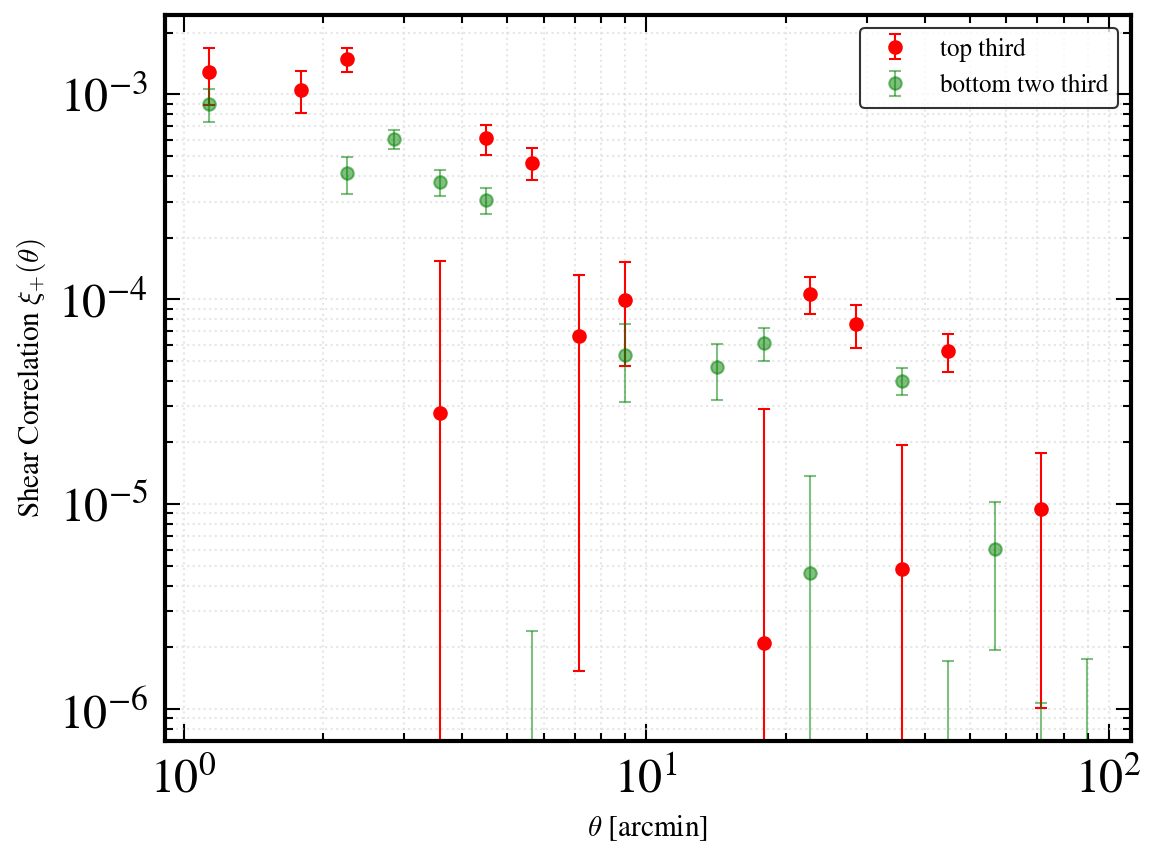

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_top_third, xip_top_third, yerr=sig_xip_top_third, label="top third", color='red', capsize=3, fmt = "o")
ax.errorbar(r_bottom_two_third, xip_bottom_two_third, yerr=sig_xip_bottom_two_third, label="bottom two third", color='green', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

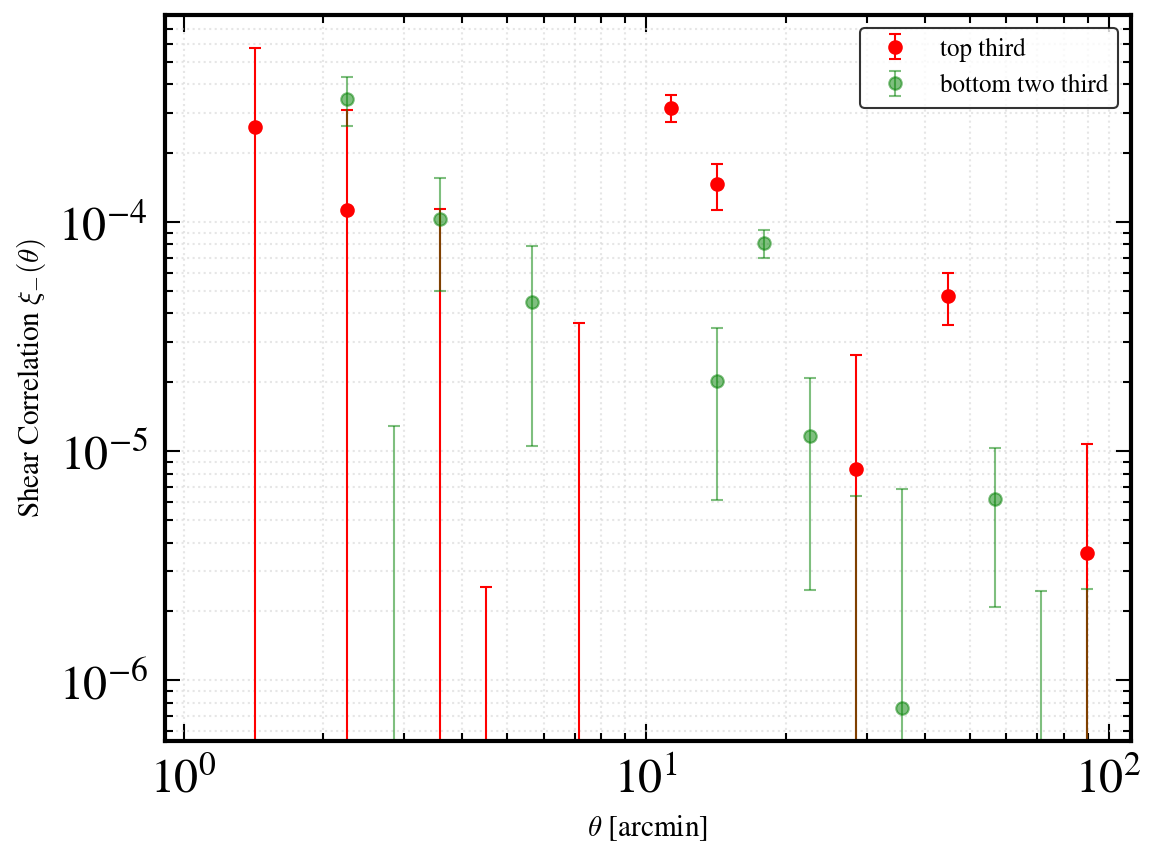

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_top_third, xim_top_third, yerr=sig_xim_top_third, label="top third", color='red', capsize=3, fmt = "o")
ax.errorbar(r_bottom_two_third, xim_bottom_two_third, yerr=sig_xim_bottom_two_third, label="bottom two third", color='green', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{-}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [40]:
mask = (hsc_catalog['Z_BEST'] >= 0.1) & (hsc_catalog['Z_BEST'] <= 1.5)
hsc_z_cut = hsc_catalog[mask]

In [41]:
ra_cut = hsc_z_cut['TARGET_RA']
dec_cut = hsc_z_cut['TARGET_DEC']
g1_cut = hsc_z_cut['e1'] 
g2_cut = hsc_z_cut['e2']

In [45]:
cat_cut = treecorr.Catalog(ra=ra_cut, dec=dec_cut, g1=g1_cut, g2=g2_cut, ra_units='degrees', dec_units='degrees')
gg_cut = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg_cut.process(cat_cut)

r_cut = np.exp(gg_cut.meanlogr)

# correlation func tions
#xi_+
xip_cut = gg_cut.xip
# # xi_-
xim_cut = gg_cut.xim

#calculate variance
sig_xip_cut = np.sqrt(gg_cut.varxip)
sig_xim_cut = np.sqrt(gg_cut.varxim)

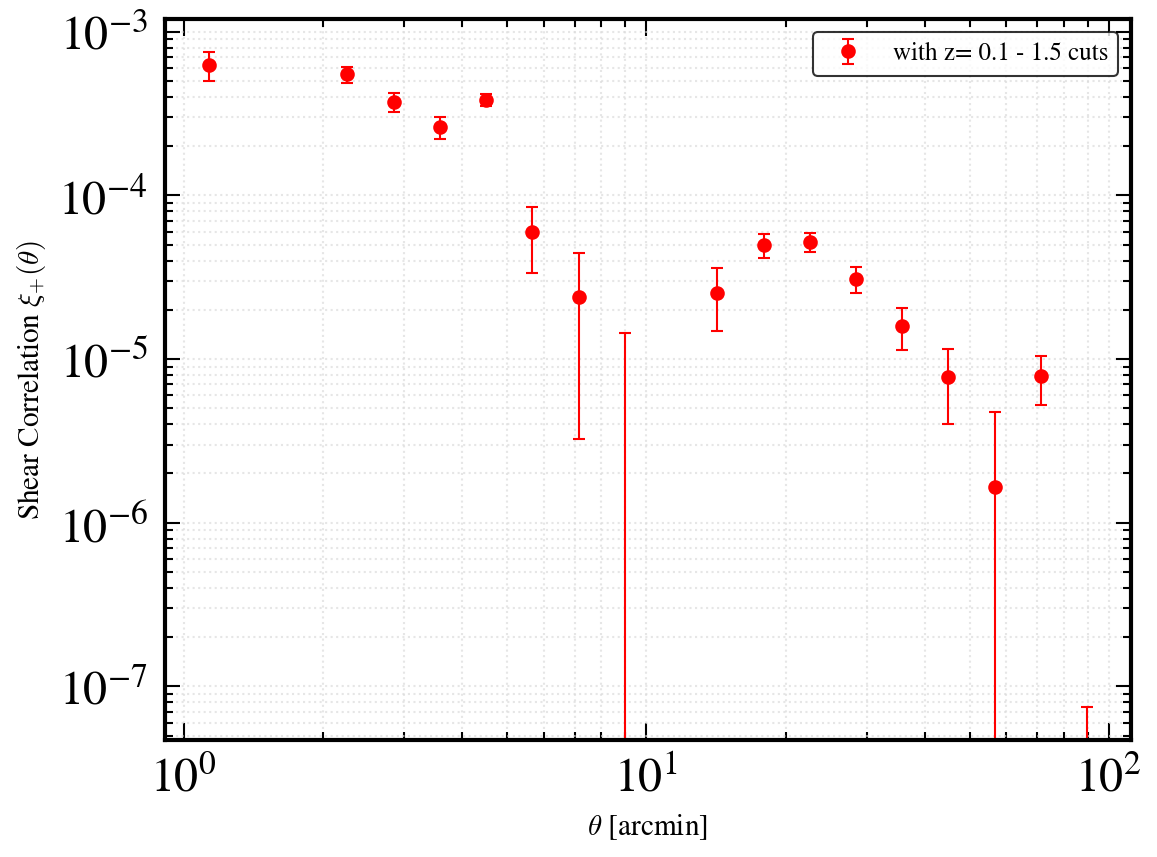

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r_cut, xip_cut, yerr=sig_xip_cut, label="with z= 0.1 - 1.5 cuts", color='red', capsize=3, fmt = "o")
#ax.errorbar(r_bottom_two_third, xim_bottom_two_third, yerr=sig_xim_bottom_two_third, label="bottom two third", color='green', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()